In [ ]:
# !pip install google.colab

## Local Inference on GPU
Model page: https://huggingface.co/microsoft/trocr-base-handwritten

⚠️ If the generated code snippets do not work, please open an issue on either the [model repo](https://huggingface.co/microsoft/trocr-base-handwritten)
			and/or on [huggingface.js](https://github.com/huggingface/huggingface.js/blob/main/packages/tasks/src/model-libraries-snippets.ts) 🙏

In [ ]:
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from PIL import Image, ImageEnhance
import requests
import cv2
import numpy as np
from PIL import Image
from matplotlib import pyplot as plt
import torch

# For **GPU**

In [ ]:

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


# For **image Processing**

In [ ]:
# def preprocess_for_lines(pil_img):
#     img = np.array(pil_img)
#     gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

#     # Adaptive threshold works better for handwriting
#     thresh = cv2.adaptiveThreshold(
#         gray,
#         255,
#         cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
#         cv2.THRESH_BINARY_INV,
#         25,
#         15
#     )

#     return img, thresh


In [ ]:
# def connect_text_horizontally(thresh):
#     kernel = cv2.getStructuringElement(
#         cv2.MORPH_RECT, (50, 1)
#     )
#     dilated = cv2.dilate(thresh, kernel, iterations=1)
#     return dilated


In [ ]:

# def split_into_lines(pil_img):
#     img, thresh = preprocess_for_lines(pil_img)
#     dilated = connect_text_horizontally(thresh)

#     projection = np.sum(dilated, axis=1)

#     lines = []
#     start = None

#     for i, val in enumerate(projection):
#         if val > 0 and start is None:
#             start = i
#         elif val == 0 and start is not None:
#             if i - start > 20:   # minimum line height
#                 lines.append(Image.fromarray(img[start:i, :]))
#             start = None

#     if start is not None:
#         lines.append(Image.fromarray(img[start:, :]))

#     return lines

In [ ]:
def convert_image_to_black_and_white(image):
    img = np.array(image)

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # Convert to BLACK & WHITE (best for handwriting)
    bw = cv2.adaptiveThreshold(
        gray,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        25,
        15
    )

    return Image.fromarray(bw)

In [ ]:

def split_bw_image_into_valid_lines(
    bw_image,
    min_height=12,
    min_black_ratio=0.01
):
    img = np.array(bw_image)

    # Ensure grayscale
    if len(img.shape) == 3:
        img = img[:, :, 0]

    h, w = img.shape

    # Row contains text if black pixel exists
    row_has_text = np.any(img < 255, axis=1)

    lines = []
    start = None

    for i, has_text in enumerate(row_has_text):
        if has_text and start is None:
            start = i
        elif not has_text and start is not None:
            line = img[start:i, :]

            # ---- FILTERS ----
            height = i - start
            black_pixels = np.sum(line < 255)
            black_ratio = black_pixels / (line.size)

            if height >= min_height and black_ratio >= min_black_ratio:
                lines.append(Image.fromarray(line))

            start = None

    # Last line
    if start is not None:
        line = img[start:h, :]
        height = h - start
        black_pixels = np.sum(line < 255)
        black_ratio = black_pixels / (line.size)

        if height >= min_height and black_ratio >= min_black_ratio:
            lines.append(Image.fromarray(line))

    return lines


In [ ]:
def trocr_multiline(
    img, processor, model, device,
    min_height=12,
    min_black_ratio=0.01
):
    lines = split_bw_image_into_valid_lines(
        img,
        min_height=min_height,
        min_black_ratio=min_black_ratio
    )

    full_text = []

    for line_img in lines:
        # Ensure PIL Image
        if not isinstance(line_img, Image.Image):
            line_img = Image.fromarray(line_img)


        # Convert to RGB mode as the processor expects 3 dimensions
        line_img_rgb = line_img.convert("RGB")

        pixel_values = processor(
            images=line_img_rgb,
            return_tensors="pt"
        ).pixel_values.to(device)

        generated_ids = model.generate(pixel_values)

        text = processor.batch_decode(
            generated_ids,
            skip_special_tokens=True
        )[0]

        full_text.append(text)

    return "\n".join(full_text)


In [ ]:
processor = TrOCRProcessor.from_pretrained('microsoft/trocr-large-handwritten')
model = VisionEncoderDecoderModel.from_pretrained('microsoft/trocr-large-handwritten').to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.23G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.23G [00:00<?, ?B/s]

Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-large-handwritten and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:

# Load image
image = Image.open("i4.jpeg").convert("RGB")
# image = Image.open("../photos/i1.jpeg").convert("RGB")

img = convert_image_to_black_and_white(image)

In [ ]:
# img must be PIL Image (your black & white image)
print(type(img), img.mode)   # sanity check

output_text = trocr_multiline(
    img, processor, model, device
)

print(output_text)


<class 'PIL.Image.Image'> L
The total number of
distinct slips needed
to point all five
digit 8200875023
1961 Gopalov


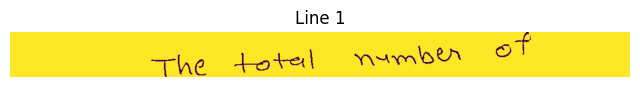

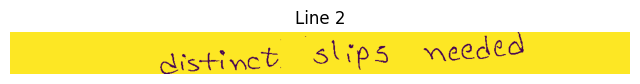

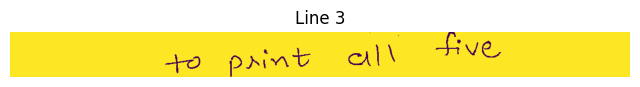

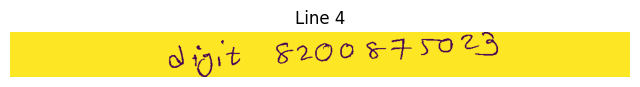

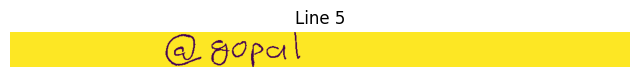

In [ ]:
lines = split_bw_image_into_valid_lines(img)

for i, line in enumerate(lines):
    plt.figure(figsize=(8, 2))
    plt.imshow(line)
    plt.axis("off")
    plt.title(f"Line {i+1}")
    plt.show()
